# Q14.
```{admonition}
:class: note
In this problem, you will develop a model to predict whether a given car gets high or low gas mileage based on the `Auto` data set.

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis, LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score as accuracy
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots

In [ ]:
auto = pd.read_csv('../../../ALL CSV FILES - 2nd Edition/Auto.csv',na_values='?').dropna()

## (a)
```{admonition}
:class: note
Create a binary variable, `mpg01`, that contains a 1 if `mpg` contains a value above its median, and a 0 if `mpg` contains a value below its median.

In [4]:
auto['mpg01'] = (auto['mpg'] >= auto['mpg'].median()).astype(int)

## (b)
```{admonition}
:class: note
Explore the data graphically in order to investigate the association between `mpg01` and other features.

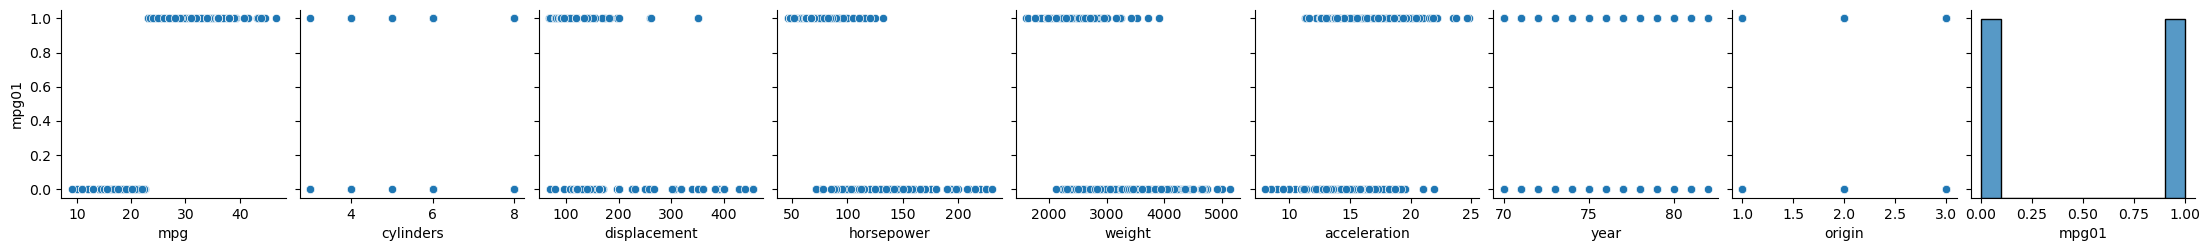

In [5]:
sns.pairplot(auto,y_vars='mpg01')
plt.show()

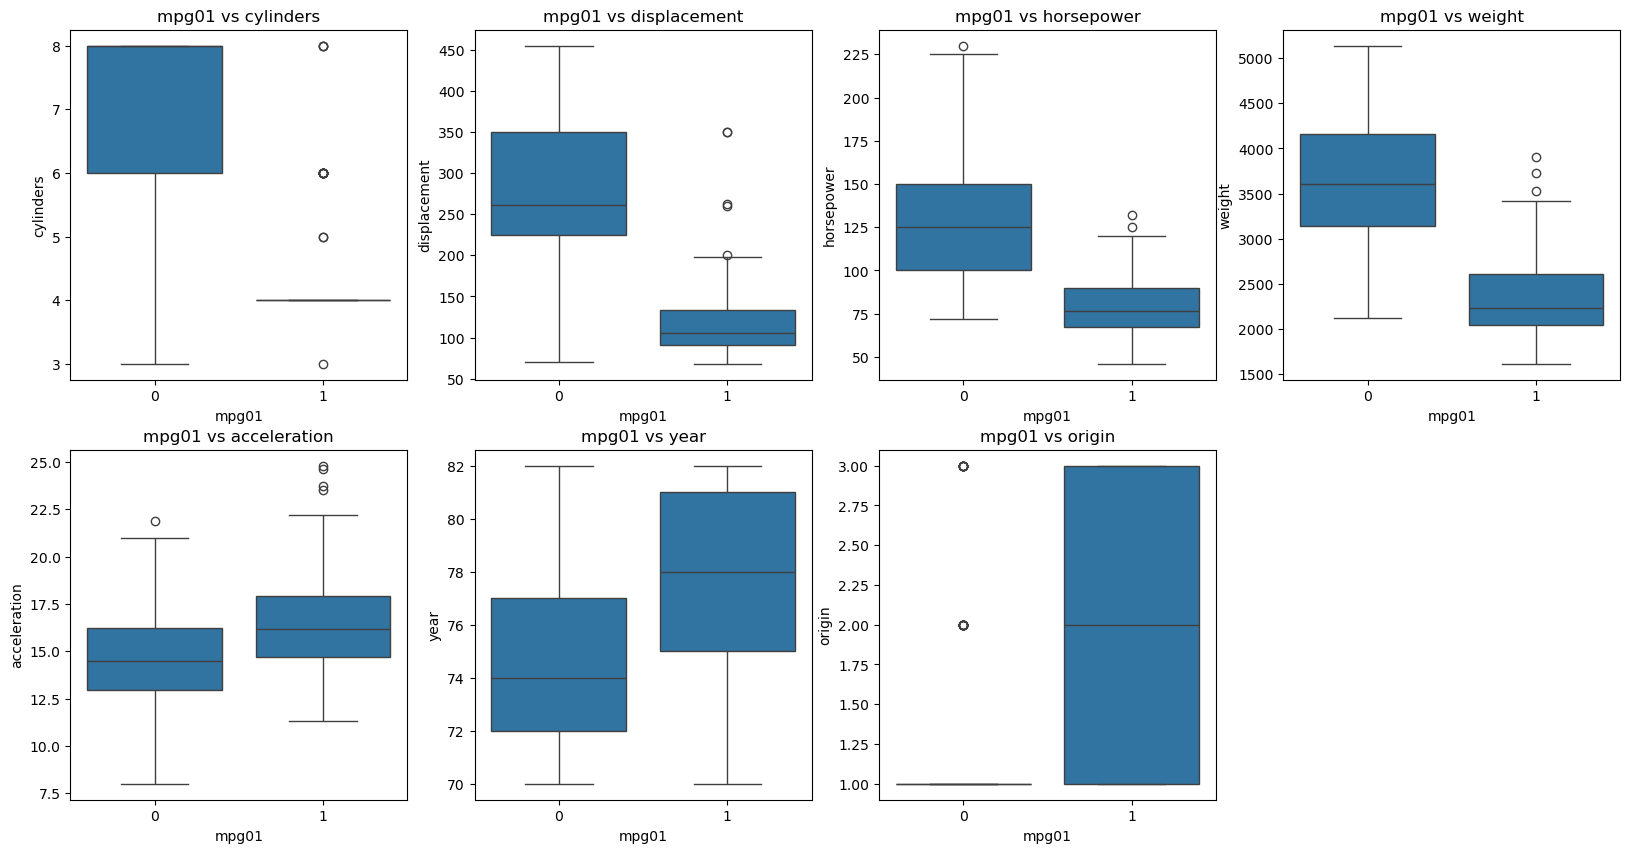

In [6]:
fig, ax = subplots(2,4,figsize=(20,10))
ax = ax.flatten()
i = 0
for col in auto.columns:
    if col not in ['mpg','mpg01','name']:
        sns.boxplot(x=auto['mpg01'],y=auto[col],ax = ax[i])
        ax[i].set_title(f'mpg01 vs {col}')
        i+=1
for j in range(i,len(ax)):
    ax[j].set_visible(False)

plt.show()

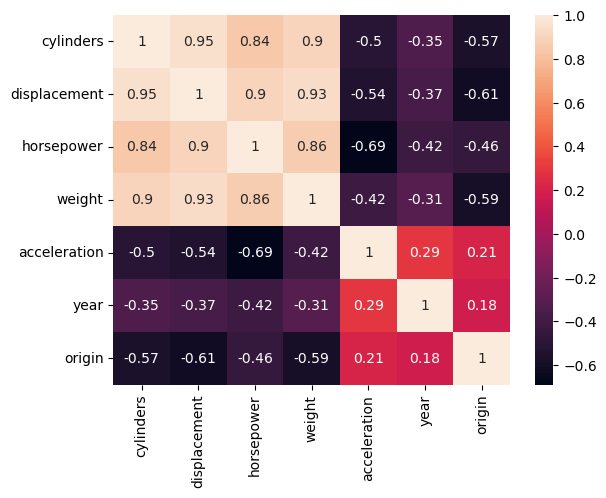

In [7]:
sns.heatmap(auto.drop(columns=['name','mpg','mpg01']).corr(),annot=True);

## (c)
```{admonition}
:class: note
Split the data into a training and test set.

In [8]:
parameters = ['acceleration','weight']
#parameters = ['cylinders', 'displacement', 'horsepower', 'weight']
#parameters = ['horsepower','acceleration','displacement','cylinders','weight']
X_train, X_test, Y_train, Y_test = train_test_split(auto[parameters],auto[['mpg01']],random_state=1728)

## (d)
```{admonition}
:class: note
Perform LDA.

In [9]:
model = LinearDiscriminantAnalysis()
model.fit(X_train,Y_train.values.ravel())
acc = accuracy(Y_test,model.predict(X_test))

y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(Y_test,y_prob)
roc_auc = auc(fpr,tpr)

print(f'Accuracy: {acc:.4f}')
print(f'Test error: {1-acc:.4f}')
print(f'AUC: {roc_auc:.4f}')

Accuracy: 0.8878
Test error: 0.1122
AUC: 0.9434


## (e)
```{admonition}
:class: note
Perform QDA.

In [10]:
model = QuadraticDiscriminantAnalysis()
model.fit(X_train,Y_train.values.ravel())
acc = accuracy(Y_test,model.predict(X_test))

y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(Y_test,y_prob)
roc_auc = auc(fpr,tpr)

print(f'Accuracy: {acc:.4f}')
print(f'Test error: {1-acc:.4f}')
print(f'AUC: {roc_auc:.4f}')

Accuracy: 0.8878
Test error: 0.1122
AUC: 0.9296


## (f)
```{admonition}
:class: note
Perform logistic regression.

In [11]:
model = LogisticRegression()
model.fit(X_train,Y_train.values.ravel())
acc = accuracy(Y_test,model.predict(X_test))

y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(Y_test,y_prob)
roc_auc = auc(fpr,tpr)

print(f'Accuracy: {acc:.4f}')
print(f'Test error: {1-acc:.4f}')
print(f'AUC: {roc_auc:.4f}')

Accuracy: 0.8571
Test error: 0.1429
AUC: 0.9417


## (g)
```{admonition}
:class: note
Perform naive Bayes.

In [12]:
model = GaussianNB()
model.fit(X_train,Y_train.values.ravel())
acc = accuracy(Y_test,model.predict(X_test))

y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(Y_test,y_prob)
roc_auc = auc(fpr,tpr)

print(f'Accuracy: {acc:.4f}')
print(f'Test error: {1-acc:.4f}')
print(f'AUC: {roc_auc:.4f}')

Accuracy: 0.8878
Test error: 0.1122
AUC: 0.9400


## (h)
```{admonition}
:class: note
Perform KNN with several values of $K$.

In [13]:
scalar = StandardScaler()
scalar.fit(X_train)
X_train_scaled = pd.DataFrame(scalar.transform(X_train),columns=parameters)
X_test_scaled = pd.DataFrame(scalar.transform(X_test),columns=parameters)

for k in range(1,101):  
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled,Y_train.values.ravel())
    acc = accuracy(Y_test,model.predict(X_test_scaled))
    
    y_prob = model.predict_proba(X_test_scaled)[:,1]
    fpr, tpr, _ = roc_curve(Y_test,y_prob)
    roc_auc = auc(fpr,tpr)

    if acc > .88:
        print(f'KNN with {k} neighbors')
        print(f'Accuracy: {acc:.4f}')
        print(f'Test error: {1-acc:.4f}')
        print(f'AUC: {roc_auc:.4f}')
        print('-'*30)

KNN with 4 neighbors
Accuracy: 0.8878
Test error: 0.1122
AUC: 0.9302
------------------------------
KNN with 7 neighbors
Accuracy: 0.8878
Test error: 0.1122
AUC: 0.9545
------------------------------
KNN with 8 neighbors
Accuracy: 0.8878
Test error: 0.1122
AUC: 0.9528
------------------------------
KNN with 9 neighbors
Accuracy: 0.8878
Test error: 0.1122
AUC: 0.9568
------------------------------
KNN with 10 neighbors
Accuracy: 0.8878
Test error: 0.1122
AUC: 0.9530
------------------------------
KNN with 16 neighbors
Accuracy: 0.8878
Test error: 0.1122
AUC: 0.9470
------------------------------
KNN with 17 neighbors
Accuracy: 0.8878
Test error: 0.1122
AUC: 0.9442
------------------------------
